# 3.1 Lab: Multi-Head Attention (MHA) Exploration

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/harshuljain13/llm-inference-at-scale/blob/master/content/03_attention_variants/03.1_mha/lab.ipynb)
[![Open In Molab](https://img.shields.io/badge/Open%20in-Molab-blue)](https://molab.cloud/github/harshuljain13/llm-inference-at-scale/blob/master/content/03_attention_variants/03.1_mha/lab.ipynb)

This lab explores Multi-Head Attention computation, visualizes attention matrices,
and measures the impact of head count on KV cache memory.

In [ ]:
# Setup: numpy and matplotlib only (no GPU required)
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

## Experiment 1: MHA Forward Pass

Implement MHA from scratch to understand the computation flow.

In [2]:
# === Parameters (change these and re-run) ===
SEQ_LEN = 16       # sequence length
D_MODEL = 512      # model hidden dimension
N_HEADS = 8        # number of attention heads
HEAD_DIM = D_MODEL // N_HEADS  # dimension per head

# Generate random input (simulating hidden states)
x = np.random.randn(SEQ_LEN, D_MODEL).astype(np.float32)

# Create per-head projection weights
W_Q = np.random.randn(N_HEADS, D_MODEL, HEAD_DIM).astype(np.float32) * 0.02
W_K = np.random.randn(N_HEADS, D_MODEL, HEAD_DIM).astype(np.float32) * 0.02
W_V = np.random.randn(N_HEADS, D_MODEL, HEAD_DIM).astype(np.float32) * 0.02
W_O = np.random.randn(N_HEADS * HEAD_DIM, D_MODEL).astype(np.float32) * 0.02

def mha_forward(x, W_Q, W_K, W_V, W_O):
    """Full MHA forward pass returning attention weights and output."""
    n_heads = W_Q.shape[0]
    head_dim = W_Q.shape[2]
    seq_len = x.shape[0]
    
    all_attn_weights = []  # store attention patterns per head
    head_outputs = []      # store output per head
    
    for i in range(n_heads):
        # Project input to Q, K, V for this head
        Q_i = x @ W_Q[i]  # [seq_len, head_dim]
        K_i = x @ W_K[i]  # [seq_len, head_dim]
        V_i = x @ W_V[i]  # [seq_len, head_dim]
        
        # Scaled dot-product attention
        scores = Q_i @ K_i.T / np.sqrt(head_dim)  # [seq_len, seq_len]
        
        # Apply causal mask (upper triangle = -inf)
        mask = np.triu(np.ones((seq_len, seq_len)), k=1) * -1e9
        scores = scores + mask
        
        # Softmax along last dimension
        exp_scores = np.exp(scores - scores.max(axis=-1, keepdims=True))
        attn_weights = exp_scores / exp_scores.sum(axis=-1, keepdims=True)
        
        # Weighted sum of values
        head_out = attn_weights @ V_i  # [seq_len, head_dim]
        
        all_attn_weights.append(attn_weights)
        head_outputs.append(head_out)
    
    # Concatenate heads and project
    concat = np.concatenate(head_outputs, axis=-1)  # [seq_len, n_heads*head_dim]
    output = concat @ W_O  # [seq_len, d_model]
    
    return output, np.array(all_attn_weights)

# Run forward pass
output, attn_weights = mha_forward(x, W_Q, W_K, W_V, W_O)
print(f'Input shape:  {x.shape}')
print(f'Output shape: {output.shape}')
print(f'Attention weights shape: {attn_weights.shape}  (n_heads, seq_len, seq_len)')

Input shape:  (16, 512)
Output shape: (16, 512)
Attention weights shape: (8, 16, 16)  (n_heads, seq_len, seq_len)


## Experiment 2: Attention Matrix Visualization

Each head learns different attention patterns. Visualize the first 4 heads.

/tmp/ipykernel_9063/2864980176.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


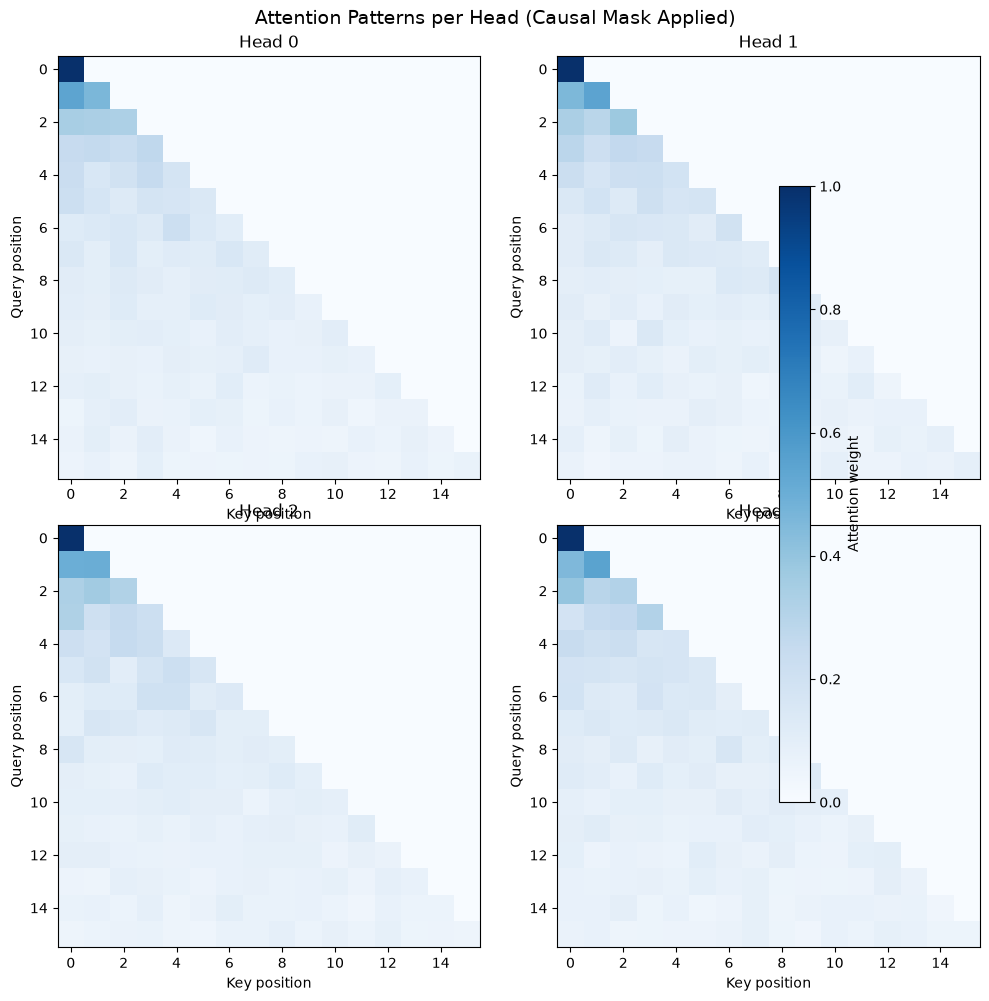

Each head attends differently: some focus locally, others broadly.


In [3]:
# Visualize attention patterns across heads
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle('Attention Patterns per Head (Causal Mask Applied)', fontsize=14)

for idx, ax in enumerate(axes.flat):
    # Plot attention matrix for head idx
    im = ax.imshow(attn_weights[idx], cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'Head {idx}', fontsize=12)
    ax.set_xlabel('Key position')
    ax.set_ylabel('Query position')

# Shared colorbar
fig.colorbar(im, ax=axes, shrink=0.8, label='Attention weight')
plt.tight_layout()
plt.savefig('attention_patterns.png', dpi=100, bbox_inches='tight')
plt.show()
print('Each head attends differently: some focus locally, others broadly.')

## Experiment 3: Head Count Impact on KV Cache Memory

The core insight: KV cache scales linearly with `n_heads` in MHA.

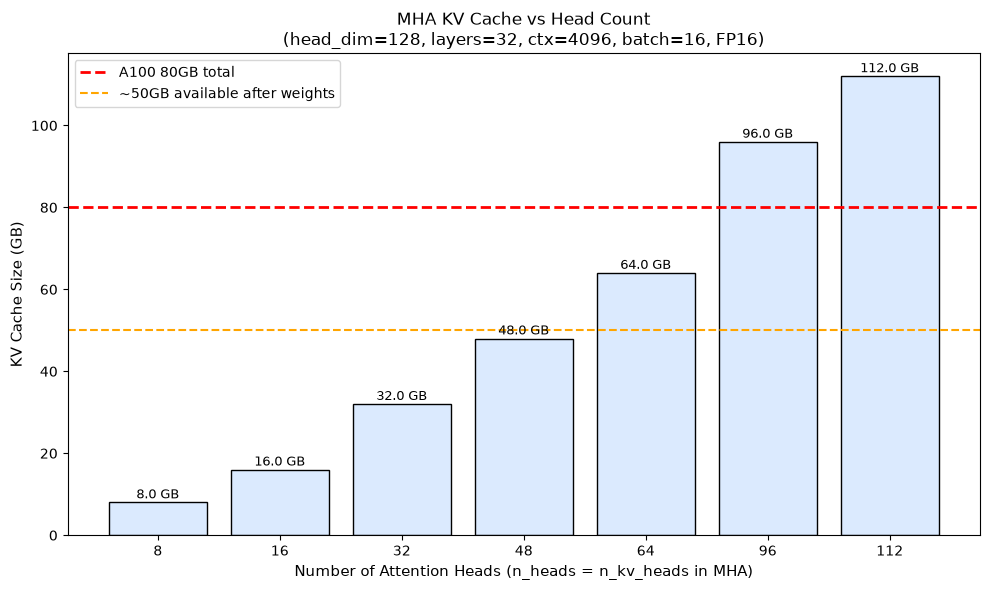

At 96 heads: 96.0 GB KV cache alone exceeds A100 capacity.


In [4]:
# === Parameters (change these and re-run) ===
HEAD_DIM_FIXED = 128     # head dimension (constant across configs)
N_LAYERS = 32            # number of transformer layers
BYTES_PER_ELEM = 2       # FP16
CONTEXT_LENGTH = 4096    # tokens in context
BATCH_SIZE = 16          # concurrent requests

# Sweep over different head counts
head_counts = [8, 16, 32, 48, 64, 96, 112]

def kv_cache_gb(n_heads, head_dim, n_layers, ctx_len, batch, bytes_per):
    """Calculate total KV cache in GB for MHA."""
    # 2 for K+V, per token, per layer, per head
    per_token = 2 * n_heads * head_dim * n_layers * bytes_per
    total = per_token * ctx_len * batch
    return total / (1024**3)  # convert to GB

# Compute KV cache for each head count
kv_sizes = [kv_cache_gb(h, HEAD_DIM_FIXED, N_LAYERS, CONTEXT_LENGTH, BATCH_SIZE, BYTES_PER_ELEM)
            for h in head_counts]

# Plot: KV cache vs head count
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(head_counts)), kv_sizes, color='#dbeafe', edgecolor='#000')

# Add A100 80GB reference line
ax.axhline(y=80, color='red', linestyle='--', linewidth=2, label='A100 80GB total')
ax.axhline(y=50, color='orange', linestyle='--', linewidth=1.5, label='~50GB available after weights')

ax.set_xticks(range(len(head_counts)))
ax.set_xticklabels([str(h) for h in head_counts])
ax.set_xlabel('Number of Attention Heads (n_heads = n_kv_heads in MHA)', fontsize=11)
ax.set_ylabel('KV Cache Size (GB)', fontsize=11)
ax.set_title(f'MHA KV Cache vs Head Count\n(head_dim={HEAD_DIM_FIXED}, layers={N_LAYERS}, ctx={CONTEXT_LENGTH}, batch={BATCH_SIZE}, FP16)',
             fontsize=12)
ax.legend(fontsize=10)

# Annotate bars with values
for bar, val in zip(bars, kv_sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f} GB', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('kv_cache_vs_heads.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'At 96 heads: {kv_sizes[5]:.1f} GB KV cache alone exceeds A100 capacity.')

## Experiment 4: Bandwidth Bottleneck

Decode latency is dominated by reading KV cache from HBM, not by compute.

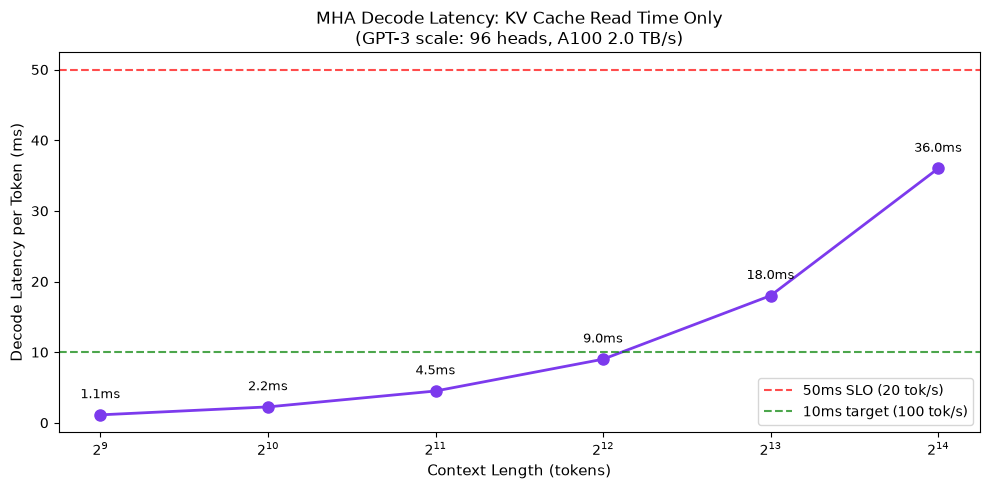

Even at 2K context, decode is already 4.6ms just reading KV from HBM.


In [5]:
# === Parameters ===
HBM_BANDWIDTH_TB_S = 2.0  # A100 HBM bandwidth in TB/s
HBM_BANDWIDTH_GB_S = HBM_BANDWIDTH_TB_S * 1000  # convert to GB/s

# Calculate time to read KV cache per decode step
context_lengths = [512, 1024, 2048, 4096, 8192, 16384]
n_heads_example = 96   # GPT-3 scale
head_dim_example = 128
n_layers_example = 96

def decode_latency_ms(ctx_len, n_heads, head_dim, n_layers, bw_gb_s):
    """Time in ms to read KV cache for one decode step."""
    # Total KV bytes to read
    kv_bytes = 2 * n_heads * head_dim * n_layers * 2 * ctx_len  # FP16
    kv_gb = kv_bytes / (1024**3)
    # Time = data / bandwidth
    time_s = kv_gb / bw_gb_s
    return time_s * 1000  # to ms

latencies = [decode_latency_ms(c, n_heads_example, head_dim_example, n_layers_example, HBM_BANDWIDTH_GB_S)
             for c in context_lengths]

# Plot decode latency vs context length
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(context_lengths, latencies, 'o-', color='#7c3aed', linewidth=2, markersize=8)

# Reference: typical SLO targets
ax.axhline(y=50, color='red', linestyle='--', alpha=0.7, label='50ms SLO (20 tok/s)')
ax.axhline(y=10, color='green', linestyle='--', alpha=0.7, label='10ms target (100 tok/s)')

ax.set_xlabel('Context Length (tokens)', fontsize=11)
ax.set_ylabel('Decode Latency per Token (ms)', fontsize=11)
ax.set_title(f'MHA Decode Latency: KV Cache Read Time Only\n(GPT-3 scale: {n_heads_example} heads, A100 {HBM_BANDWIDTH_TB_S} TB/s)',
             fontsize=12)
ax.legend(fontsize=10)
ax.set_xscale('log', base=2)

# Annotate each point
for ctx, lat in zip(context_lengths, latencies):
    ax.annotate(f'{lat:.1f}ms', (ctx, lat), textcoords='offset points',
               xytext=(0, 12), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('bandwidth_bottleneck.png', dpi=100, bbox_inches='tight')
plt.show()
print('Even at 2K context, decode is already 4.6ms just reading KV from HBM.')

## Key Takeaways

1. MHA gives maximum representational power: each head has independent K, V projections
2. KV cache scales as `2 x n_heads x head_dim x n_layers x bytes` per token
3. At GPT-3 scale (96 heads), KV cache alone can exhaust an A100's 80GB
4. Decode latency is dominated by KV cache read bandwidth, not compute
5. This motivates MQA (Module 3.2) and GQA (Module 3.3) which reduce n_kv_heads